# Heading 1

## Heading 2.1
## Heading 2.2

### Heading

#### Heading

##### Heading

**Example text to describe the cell below**

def f(x):
    """a docstring"""
    return x**2

f(3)

```python
print 'Hello world'
```

\begin{equation}
e^x=x+57
\end{equation}


|Test|Table|1|
|---|---|---|
|Content|Example|For table|


## The book sheet

Given that I'm a big reader, my Christmas(/Sinterklaas) wish lists tend to include a generic request for "books". When I heard that my siblings were having to sneak up to my room to check whether I already owned the book they intended to gift me, I decided there must be a better way. I created a spreadsheet to document books I owned and books I still wanted to read, which I share with the family every year. In addition, now that I had it, it became an interesting document with which to reflect on my reading habits.

The most obvious immediate use was to check for my favourite authors and the editions of their books that I tended to buy:

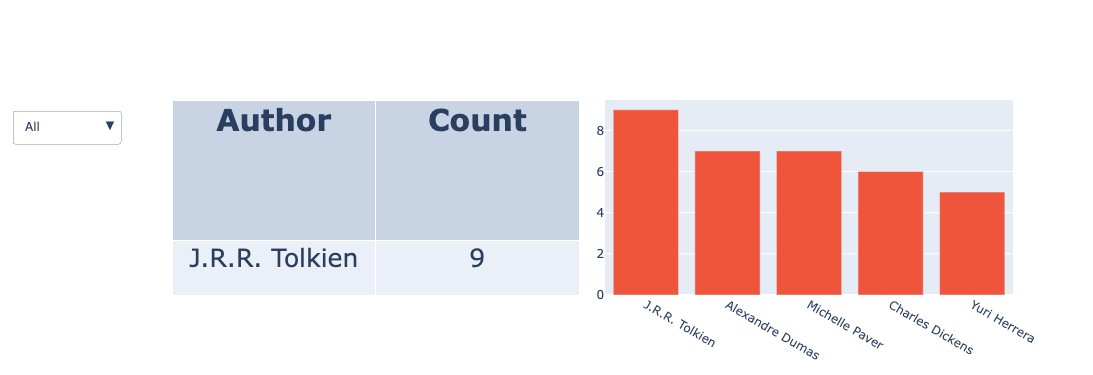

In [19]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import constants
from constants import gsheet_name

def read_gsheet(gsheetkey,gsheet_name):
    url=f'https://docs.google.com/spreadsheet/ccc?key={gsheetkey}&output=xlsx'
    book_sheet_df = pd.read_excel(url,sheet_name=gsheet_name)
    return book_sheet_df

#Graph showing top 5 authors by language
def create_author_podium_chart(book_sheet_df):
    #Set up the two subplots: a table and a bar, each occupying half of the screen split vertically
    author_podium_chart=make_subplots(
    rows=1, cols=2,
    shared_yaxes=True,
    horizontal_spacing=0.03,
    specs=[[{'type':'table'},{'type':'bar'}]]
    )
    
    #Create possible dataframes
    variable_df_Author_All=book_sheet_df.groupby('Author')['Author'].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_Author_English=book_sheet_df.query("Language=='English'").groupby('Author')['Author'].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_Author_Nederlands=book_sheet_df.query("Language=='Nederlands'").groupby('Author')['Author'].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_Author_Español=book_sheet_df.query("Language=='Español'").groupby('Author')['Author'].count().sort_values(ascending=False).head().reset_index(name='Count')

    #Set up four tables
    author_podium_chart.add_trace(
        go.Table(
            name='Author_All',
            header_values=['Author','Count'],
            cells_values=[variable_df_Author_All[k].tolist() for k in variable_df_Author_All],
            visible=True
        ),
        row=1,col=1,
        )
    author_podium_chart.add_trace(
        go.Table(
            name='Author_English',
            header_values=['Author','Count'],
            cells_values=[variable_df_Author_English[k].tolist() for k in variable_df_Author_English],
            visible=False
        ),
        row=1,col=1
        )
    author_podium_chart.add_trace(
        go.Table(
            name='Author_Nederlands',
            header_values=['Author','Count'],
            cells_values=[variable_df_Author_Nederlands[k].tolist() for k in variable_df_Author_Nederlands],
            visible=False
        ),
        row=1,col=1
        )
    author_podium_chart.add_trace(
        go.Table(
            name='Author_Español',
            header_values=['Author','Count'],
            cells_values=[variable_df_Author_Español[k].tolist() for k in variable_df_Author_Español],
            visible=False
        ),
        row=1,col=1
        )
    author_podium_chart.update_traces(
        header_height=140,
        header_font_size=30,
        header_font_weight=999,
        cells_height=124,
        cells_font_size=25
    )

    #Set up four bars
    author_podium_chart.add_trace(
        go.Bar(
            name='Author_All',
            x=variable_df_Author_All['Author'],
            y=variable_df_Author_All['Count'],
            visible=True
        ),
        row=1,col=2
    )
    author_podium_chart.add_trace(
        go.Bar(
            name='Author_English',
            x=variable_df_Author_English['Author'],
            y=variable_df_Author_English['Count'],
            visible=False
        ),
        row=1,col=2
    )
    author_podium_chart.add_trace(
        go.Bar(
            name='Author_Nederlands',
            x=variable_df_Author_Nederlands['Author'],
            y=variable_df_Author_Nederlands['Count'],
            visible=False
        ),
        row=1,col=2
    ) 
    author_podium_chart.add_trace(
        go.Bar(
            name='Author_Español',
            x=variable_df_Author_Español['Author'],
            y=variable_df_Author_Español['Count'],
            visible=False
        ),
        row=1,col=2
    )

    #Add buttons that modify which of the tables/bar charts you can see
    author_podium_chart.update_layout(
        updatemenus=[
        #Add button that chooses languages
        {'buttons':[{
                    'label': "All",
                    'method': "update",
                    'args':[
                        {'visible': [True,False,False,False,True,False,False,False]}]},
                    {
                    'label': "English",
                    'method': "update",
                    'args':[
                        {'visible': [False,True,False,False,False,True,False,False]}]},
                    {
                    'label': "Nederlands",
                    'method': "update",
                    'args':[
                        {'visible': [False,False,True,False,False,False,True,False]}]},
                    {
                    'label': "Español",
                    'method': "update",
                    'args':[
                        {'visible': [False,False,False,True,False,False,False,True]}]},
            ],
            'type':'dropdown',
            'direction':'down',
            'pad': {"r": 10, "t": 10},
            'showactive': True}
    ])
    return author_podium_chart

book_sheet_df=read_gsheet(gsheetkey=gsheetkey,gsheet_name=gsheet_name)
author_podium_chart=create_author_podium_chart(book_sheet_df=book_sheet_df)
author_podium_chart.show()